In [3]:
import pickle

with open("yoochoose1_64/train.txt", "rb") as f:
    data = pickle.load(f)

# Giải nén dữ liệu thành Tuple 3 phần tử: (Items, Categories, Labels)
out_seqs, cat_seqs, labs = data

print(f"Tổng số phiên huấn luyện: {len(out_seqs)}")
print("-" * 50)

# In thử 10 dòng đầu tiên để kiểm tra
for i in range(min(10, len(out_seqs))):
    print(f"Phiên {i}:")
    print(f"  - Items : {out_seqs[i]}")
    print(f"  - Cats  : {cat_seqs[i]}")
    print(f"  -> Target Item: {labs[i]}\n")

Tổng số phiên huấn luyện: 369859
--------------------------------------------------
Phiên 0:
  - Items : [37151, 37149, 37149]
  - Cats  : [5, 7, 7]
  -> Target Item: 37146

Phiên 1:
  - Items : [37151, 37149]
  - Cats  : [5, 7]
  -> Target Item: 37149

Phiên 2:
  - Items : [37151]
  - Cats  : [5]
  -> Target Item: 37149

Phiên 3:
  - Items : [2613, 33285, 34264, 34641, 35021, 17064]
  - Cats  : [3, 3, 13, 2, 2, 14]
  -> Target Item: 35162

Phiên 4:
  - Items : [2613, 33285, 34264, 34641, 35021]
  - Cats  : [3, 3, 13, 2, 2]
  -> Target Item: 17064

Phiên 5:
  - Items : [2613, 33285, 34264, 34641]
  - Cats  : [3, 3, 13, 2]
  -> Target Item: 35021

Phiên 6:
  - Items : [2613, 33285, 34264]
  - Cats  : [3, 3, 13]
  -> Target Item: 34641

Phiên 7:
  - Items : [2613, 33285]
  - Cats  : [3, 3]
  -> Target Item: 34264

Phiên 8:
  - Items : [2613]
  - Cats  : [3]
  -> Target Item: 33285

Phiên 9:
  - Items : [1756, 120]
  - Cats  : [3, 3]
  -> Target Item: 120



In [1]:
import csv
from collections import Counter
import time

# Điền đúng đường dẫn tới file dữ liệu của bạn
filename = 'yoochoose/yoochoose-clicks.dat' 

category_counts = Counter()
missing_category = 0
total_rows = 0

print(f"Bắt đầu quét file: {filename}...")
start_time = time.time()

try:
    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',')
        for row in reader:
            total_rows += 1
            
            # Kiểm tra nếu dòng bị lỗi, không đủ 4 cột
            if len(row) < 4:
                missing_category += 1
                continue
            
            cat = row[3].strip()
            
            # Kiểm tra danh mục rỗng
            if cat == '':
                missing_category += 1
            else:
                category_counts[cat] += 1
            
            # In tiến độ cho đỡ sốt ruột (mỗi 5 triệu dòng)
            if total_rows % 5000000 == 0:
                print(f" -> Đã quét {total_rows:,} dòng...")

    print(f"\n======== KẾT QUẢ THỐNG KÊ (Thời gian: {time.time() - start_time:.2f}s) ========")
    print(f"1. Tổng số dòng dữ liệu : {total_rows:,}")
    print(f"2. Số dòng bị thiếu/rỗng : {missing_category:,}")
    print(f"3. Tổng số LOẠI danh mục : {len(category_counts):,}")
    
    print("\n--- Chi tiết các danh mục ĐẶC BIỆT (Chứa chữ cái) ---")
    special_cats = {cat: count for cat, count in category_counts.items() if not cat.isdigit()}
    if special_cats:
        for cat, count in special_cats.items():
            print(f" + Danh mục '{cat}' : xuất hiện ở {count:,} dòng")
    else:
        print(" + Không có danh mục chứa chữ cái.")

    print("\n--- Top 10 danh mục (bằng số) xuất hiện nhiều nhất ---")
    # Lọc ra các category là số để in top 10
    numeric_cats = {cat: count for cat, count in category_counts.items() if cat.isdigit()}
    top_10 = Counter(numeric_cats).most_common(10)
    for cat, count in top_10:
        print(f" + Danh mục '{cat}' : xuất hiện ở {count:,} dòng")

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file '{filename}'. Vui lòng kiểm tra lại đường dẫn.")

Bắt đầu quét file: yoochoose/yoochoose-clicks.dat...
 -> Đã quét 5,000,000 dòng...
 -> Đã quét 10,000,000 dòng...
 -> Đã quét 15,000,000 dòng...
 -> Đã quét 20,000,000 dòng...
 -> Đã quét 25,000,000 dòng...
 -> Đã quét 30,000,000 dòng...

======== KẾT QUẢ THỐNG KÊ (Thời gian: 69.85s) ========
1. Tổng số dòng dữ liệu : 33,003,945
2. Số dòng bị thiếu/rỗng : 0
3. Tổng số LOẠI danh mục : 340

--- Chi tiết các danh mục ĐẶC BIỆT (Chứa chữ cái) ---
 + Danh mục 'category_id' : xuất hiện ở 1 dòng
 + Danh mục 'S' : xuất hiện ở 10,769,610 dòng

--- Top 10 danh mục (bằng số) xuất hiện nhiều nhất ---
 + Danh mục '0' : xuất hiện ở 16,337,653 dòng
 + Danh mục '1' : xuất hiện ở 1,671,754 dòng
 + Danh mục '2' : xuất hiện ở 1,292,249 dòng
 + Danh mục '3' : xuất hiện ở 789,713 dòng
 + Danh mục '4' : xuất hiện ở 480,569 dòng
 + Danh mục '5' : xuất hiện ở 471,923 dòng
 + Danh mục '6' : xuất hiện ở 414,696 dòng
 + Danh mục '7' : xuất hiện ở 389,910 dòng
 + Danh mục '9' : xuất hiện ở 105,282 dòng
 + Danh mục

In [2]:
!pip3 install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 59.4 kB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 133.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 42.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 144.3 kB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 288.9 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 285.3 kB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


Đã lưu biểu đồ thành file 'baseline_performance.png'


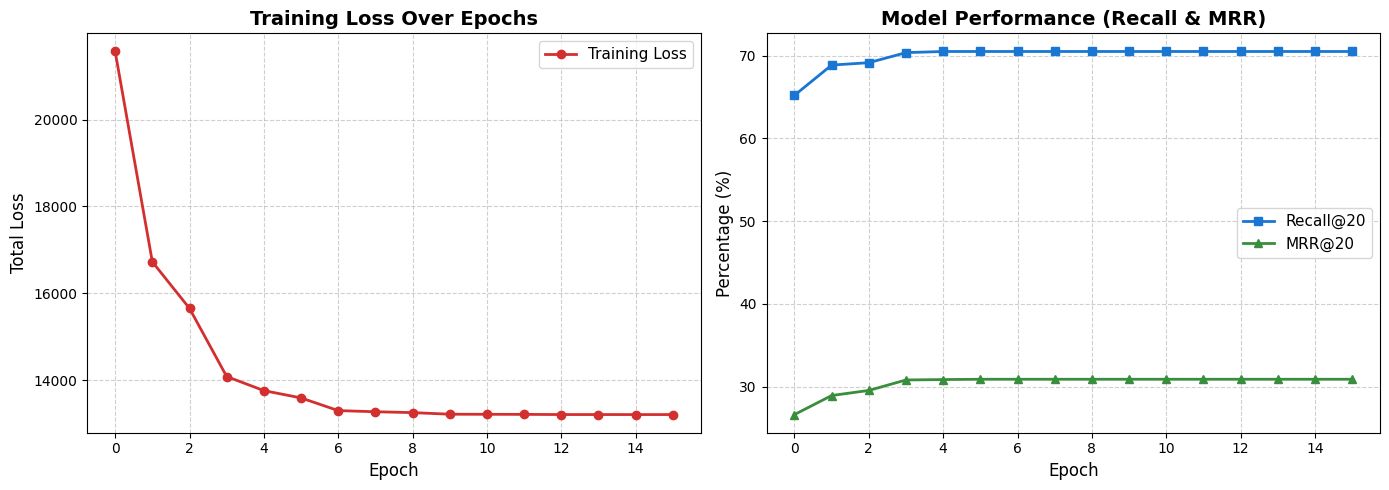

In [3]:
import re
import matplotlib.pyplot as plt

def plot_training_log(log_file_path):
    epochs = []
    losses = []
    recalls = []
    mrrs = []

    # Định nghĩa quy tắc (Regex) để tìm đúng dòng chứa số liệu
    # Tìm dòng chứa tổng Loss của mỗi epoch (bỏ qua các dòng log chứa dấu "[" của từng batch)
    loss_pattern = re.compile(r'\s+Loss:\s+([0-9.]+)')
    # Tìm dòng chứa kết quả Recall và MRR
    metric_pattern = re.compile(r'Recall@20:\s+([0-9.]+)\s+MMR@20:\s+([0-9.]+)')

    # Đọc file log
    try:
        with open(log_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Tìm Loss tổng
                loss_match = loss_pattern.search(line)
                if loss_match and "Loss:" in line and "[" not in line:
                    losses.append(float(loss_match.group(1)))

                # Tìm Recall và MRR
                metric_match = metric_pattern.search(line)
                if metric_match:
                    recalls.append(float(metric_match.group(1)))
                    mrrs.append(float(metric_match.group(2)))
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file '{log_file_path}'. Vui lòng kiểm tra lại tên file.")
        return

    # Tạo danh sách trục X (Epoch 0, 1, 2...)
    epochs = list(range(len(recalls)))

    # --- BẮT ĐẦU VẼ BIỂU ĐỒ CHUẨN BÁO CÁO KHOA HỌC ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Biểu đồ 1: Sự sụt giảm của Loss
    ax1.plot(epochs, losses, color='#D32F2F', marker='o', linestyle='-', linewidth=2, markersize=6, label='Training Loss')
    ax1.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Total Loss', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11)

    # Biểu đồ 2: Sự tăng trưởng của Recall và MRR
    ax2.plot(epochs, recalls, color='#1976D2', marker='s', linestyle='-', linewidth=2, markersize=6, label='Recall@20')
    ax2.plot(epochs, mrrs, color='#388E3C', marker='^', linestyle='-', linewidth=2, markersize=6, label='MRR@20')
    ax2.set_title('Model Performance (Recall & MRR)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Percentage (%)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(fontsize=11)

    # Căn chỉnh và hiển thị
    plt.tight_layout()
    # Lưu ảnh nét cao (300 dpi) ra thư mục hiện tại để bạn chèn thẳng vào file Word/LaTeX
    plt.savefig('baseline_performance.png', dpi=300) 
    print("Đã lưu biểu đồ thành file 'baseline_performance.png'")
    
    plt.show()

# Điền đúng tên file log của bạn vào đây
plot_training_log('training_log_20260324_182149.log')